In [125]:
import numpy as np
import matplotlib.pyplot as plt

Current is a balance:

Electric field trying to accelerate electrons.
Scattering trying to randomize them.

That balance creates a constant drift velocity, which is exactly what we'll simulate.

In [126]:
N = 300          # Number of electrons
width = 10       # Box width
height = 5       # Box height
dt = 0.05        # Time step

In [173]:
q = -1
m = 1
Ex = 10

ax = q * Ex / m

Initial Positions and velocities

In [174]:
x = np.random.uniform(0, width, N)
y = np.random.uniform(0, height, N)

vx = np.random.normal(0, 1, N)
vy = np.random.normal(0, 1, N)


In [186]:
drift = []
P = 0.2

for step in range(500):

   
    #accelerate electrons
    vx += ax * dt 

    #move electrons about
    x += vx * dt
    y += vy * dt

    #beriodic boundaries
    x = x % width
    y = y % height


    # Collisions
    collision = np.random.rand(N) < P
    vx[collision] = np.random.normal(0, 1, np.sum(collision))
    vy[collision] = np.random.normal(0, 1, np.sum(collision))


    drift.append(np.mean(vx))

    print(np.sum(collision))

46
60
67
58
65
55
47
72
57
59
56
64
50
62
66
62
75
65
67
61
61
56
69
57
74
60
63
52
66
62
59
64
50
58
38
53
48
62
68
53
81
61
68
65
64
58
56
57
59
58
68
67
63
56
59
54
61
60
64
72
62
61
58
51
64
51
53
72
66
53
56
52
48
53
52
59
71
56
58
52
69
63
56
63
56
50
51
74
69
57
60
65
47
56
71
53
65
57
61
62
69
46
67
62
51
65
76
57
63
56
52
58
52
63
62
60
55
55
63
61
66
48
59
54
64
61
75
65
57
53
52
69
67
66
60
64
60
54
61
54
64
66
55
62
59
56
58
60
58
62
45
61
56
72
66
60
58
62
63
70
62
52
55
66
42
63
64
59
57
56
59
65
68
61
69
60
52
61
45
58
65
69
63
57
60
46
56
52
56
67
59
62
70
66
60
67
52
75
57
69
67
57
46
52
62
51
54
55
63
59
47
61
63
61
58
55
53
66
50
59
54
60
52
58
60
67
62
63
62
55
71
48
54
71
54
67
46
62
64
64
61
52
65
59
65
75
61
44
53
70
51
59
53
67
52
51
60
57
60
63
48
73
58
59
66
62
63
52
54
71
59
55
61
60
66
68
59
43
71
66
65
53
75
68
74
67
69
69
65
52
52
64
72
48
65
58
62
71
59
54
70
69
51
52
57
62
71
49
52
55
53
68
65
70
60
66
46
56
53
73
56
51
62
50
57
67
60
57
74
69
49
64
61
6

In [187]:
print(np.mean(vx))

-2.146189187762997


Average vx: -2.146189187762997
Average vy: 0.031052342818690477


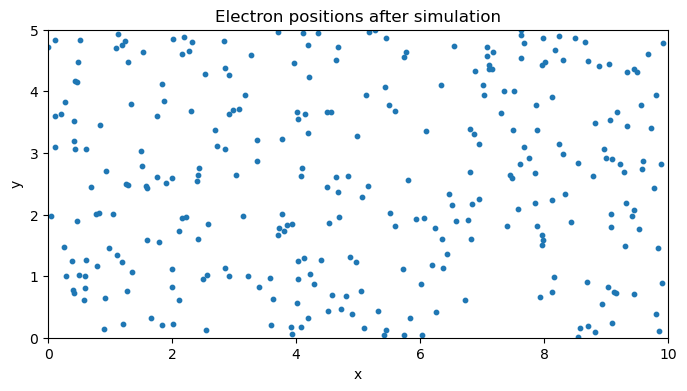

In [188]:
print("Average vx:", np.mean(vx))
print("Average vy:", np.mean(vy))

plt.figure(figsize=(8,4))
plt.scatter(x, y, s=10)
plt.xlim(0, width)
plt.ylim(0, height)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Electron positions after simulation")
plt.show()

Plotting drift velocity

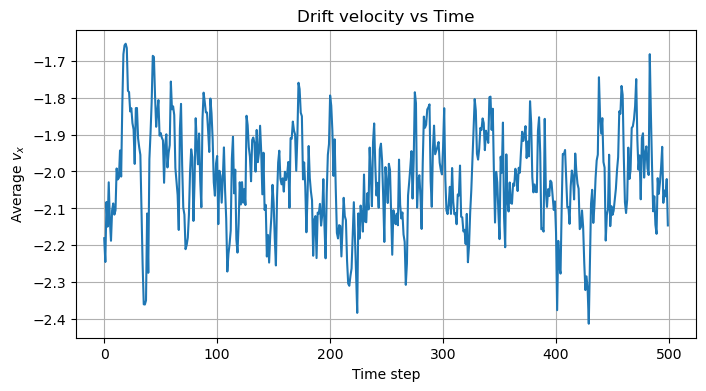

In [189]:
plt.figure(figsize=(8,4))
plt.plot(drift)
plt.xlabel("Time step")
plt.ylabel("Average $v_x$")
plt.title("Drift velocity vs Time")
plt.grid(True)
plt.show()

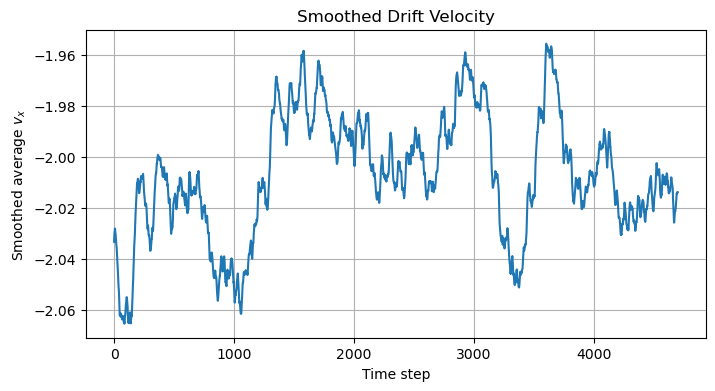

In [185]:
window = 300
smooth = np.convolve(drift, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8,4))
plt.plot(smooth)
plt.xlabel("Time step")
plt.ylabel("Smoothed average $v_x$")
plt.title("Smoothed Drift Velocity")
plt.grid(True)
plt.show()